<a href="https://colab.research.google.com/github/inaammkarim/IndoLike/blob/main/Task4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [7]:
data = pd.read_csv('/content/train.csv')
test_data=pd.read_csv('/content/test.csv')
print(data.head())
print(test_data.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
  

In [8]:
data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [9]:
test_data.isnull().sum()

,0
PassengerId,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1
Cabin,327


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   Survived    891 non-null    int64   
 1   Pclass      891 non-null    int64   
 2   Sex         891 non-null    object  
 3   Age         891 non-null    float64 
 4   SibSp       891 non-null    int64   
 5   Parch       891 non-null    int64   
 6   Fare        891 non-null    float64 
 7   Cabin       204 non-null    object  
 8   Embarked    891 non-null    object  
 9   Age_Fare    891 non-null    float64 
 10  Age_Binned  891 non-null    category
dtypes: category(1), float64(3), int64(4), object(3)
memory usage: 70.8+ KB
None
         Survived      Pclass         Age       SibSp       Parch        Fare  \
count  891.000000  891.000000  891.000000  891.000000  891.000000  891.000000   
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208   
std      0.486592    0.83

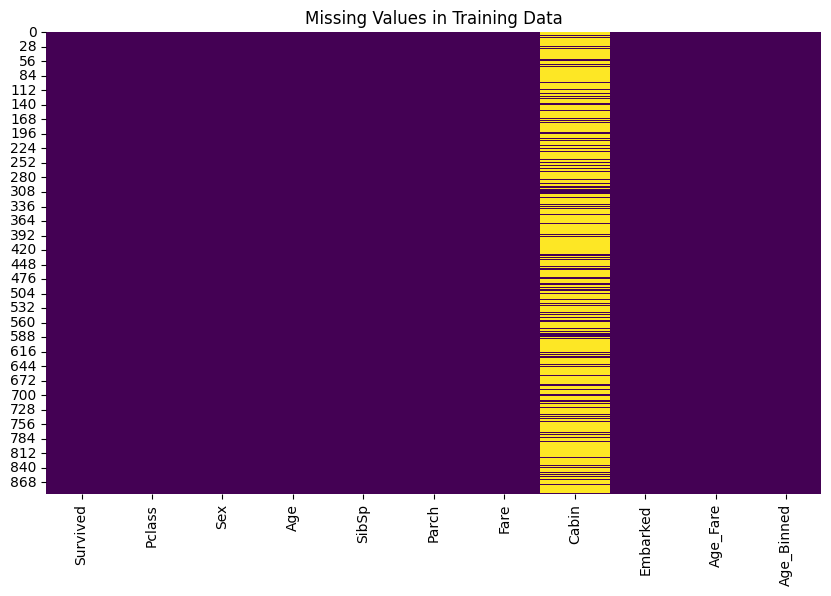

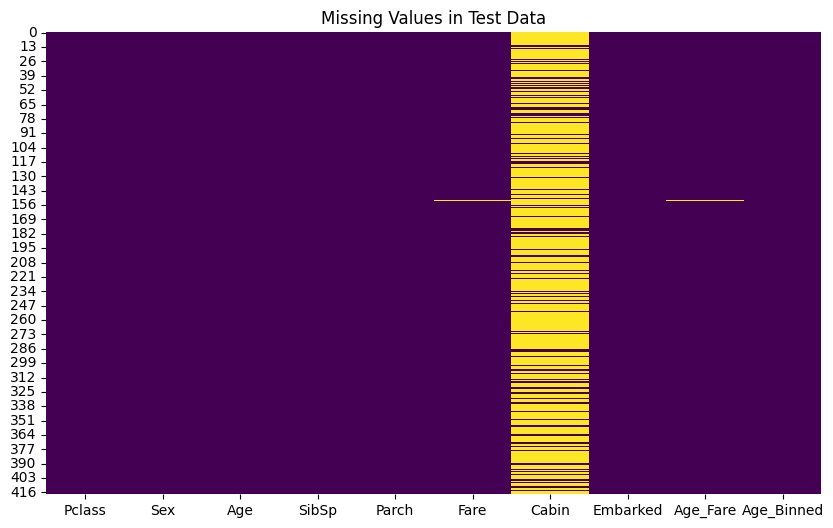

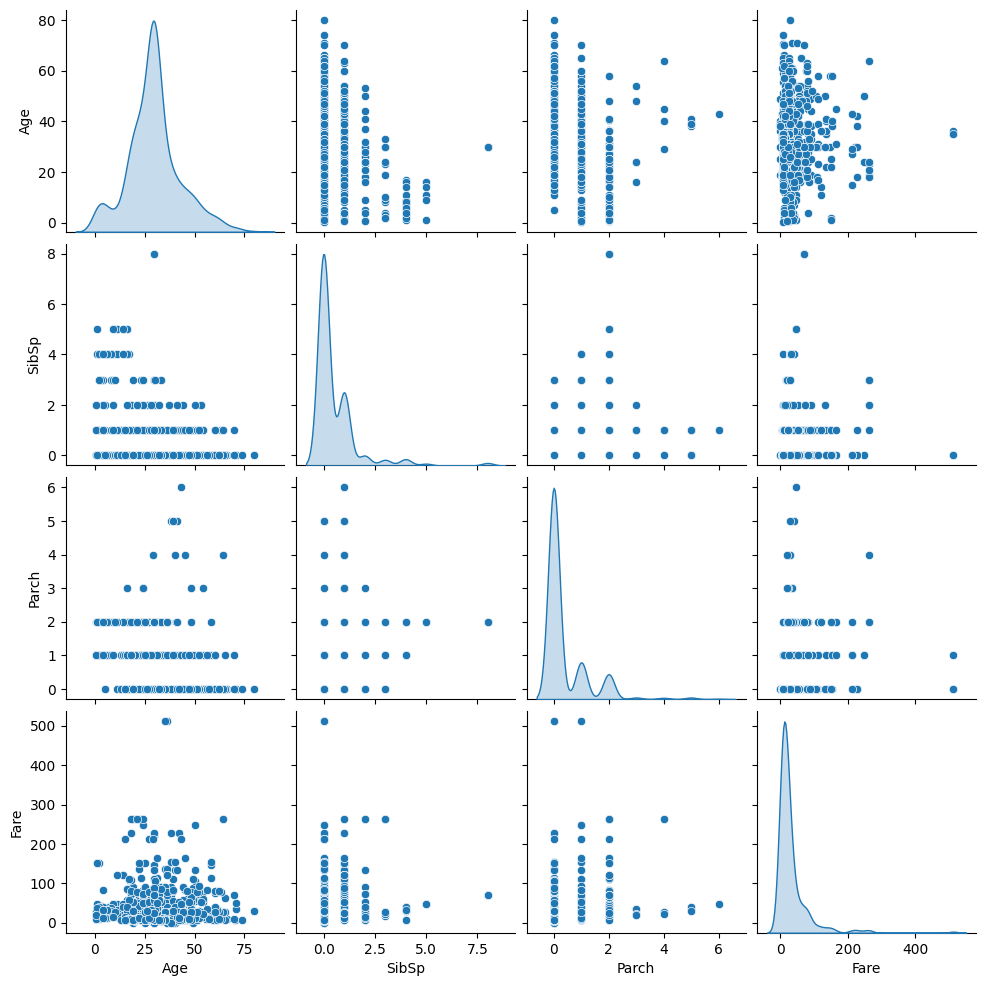

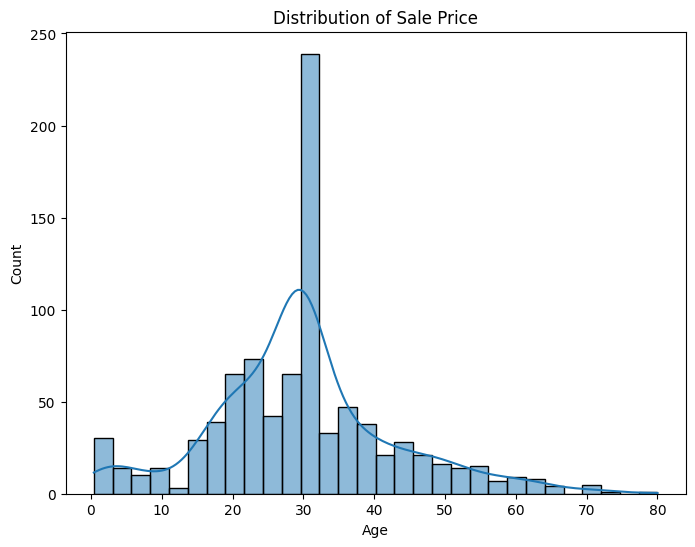

Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Cabin         0
Embarked      0
Age_Fare      0
Age_Binned    0
dtype: int64
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Cabin         0
Embarked      0
Age_Fare      0
Age_Binned    0
dtype: int64


In [14]:
print(data.info())
print(data.describe())
print(test_data.info())
print(test_data.describe())

# Visualize missing values
plt.figure(figsize=(10, 6))
sns.heatmap(data.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values in Training Data')
plt.show()

plt.figure(figsize=(10, 6))
sns.heatmap(test_data.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values in Test Data')
plt.show()

# Explore relationships between variables (example)
sns.pairplot(data[['Sex', 'Age', 'SibSp', 'Parch','Fare','Cabin','Embarked']], diag_kind='kde')
plt.show()


# Analyze distributions of key features (example)
plt.figure(figsize=(8, 6))
sns.histplot(data['Age'], kde=True)
plt.title('Distribution of Sale Price')
plt.show()

# Handle missing values (example: fill with median for numerical)
numerical_cols = data.select_dtypes(include=np.number).columns
for col in numerical_cols:
    if data[col].isnull().any():
        data[col] = data[col].fillna(data[col].median())

numerical_cols_test = test_data.select_dtypes(include=np.number).columns
for col in numerical_cols_test:
    if test_data[col].isnull().any():
        test_data[col] = test_data[col].fillna(test_data[col].median())

# Handle missing values (example: fill with mode for categorical)
categorical_cols = data.select_dtypes(exclude=np.number).columns
for col in categorical_cols:
    if data[col].isnull().any():
        data[col] = data[col].fillna(data[col].mode()[0])

categorical_cols_test = test_data.select_dtypes(exclude=np.number).columns
for col in categorical_cols_test:
    if test_data[col].isnull().any():
        test_data[col] = test_data[col].fillna(test_data[col].mode()[0])


# Verify missing values are handled
print(data.isnull().sum())
print(test_data.isnull().sum())
